## Problem Statement
Customer churn is a major challenge for telecom companies.

This project builds a predictive model to identify customers at risk of churning and extract insights to reduce churn.

In [ ]:
# 2. Begin by importing the necessary libraries for data analysis and visualisation. 

# pandas: for data manipulation and analysis (e.g., DataFrames, reading CSV files, cleaning data)
import pandas as pd  

# numpy: provides support for numerical operations, arrays, and mathematical functions
import numpy as np  

# matplotlib.pyplot: for creating basic plots and visualizations (line plots, bar charts, etc.)
import matplotlib.pyplot as plt  

# seaborn: built on matplotlib; for more advanced and visually appealing statistical plots
import seaborn as sns  

# train_test_split: splits data into training and testing sets
from sklearn.model_selection import train_test_split

#Logistic Regression
from sklearn.linear_model import LogisticRegression

# MinMaxScaler: scales features to a fixed range (usually 0 to 1), useful for distance-based models like KMeans
# LabelEncoder: converts categorical labels into numeric values
from sklearn.preprocessing import LabelEncoder, MinMaxScaler  

# accuracy_score: calculates the proportion of correct predictions made by the model
# confusion_matrix: shows counts of true vs predicted labels (TP, FP, TN, FN)
# precision_score: measures how many predicted positive cases are actually correct (TP / (TP + FP))
# recall_score: measures how many actual positive cases were correctly identified (TP / (TP + FN))
from sklearn.metrics import accuracy_score, confusion_matrix , precision_score, recall_score

# DecisionTreeClassifier: a model that splits data into branches to make predictions
from sklearn.tree import DecisionTreeClassifier  

# RandomForestClassifier: ensemble of decision trees using bagging to improve accuracy
from sklearn.ensemble import RandomForestClassifier

In [329]:
# 3. Load the Telco Customer Churn dataset provided 
df = pd.read_csv("Telco-Customer-Churn.csv")

In [330]:
# Check dataframe shape
df.shape

(7043, 21)

In [331]:
# Summarize dataframe ['Unique', 'Missing (IsNull)', 'Nan (isNA)', 'Dtype']
summary = pd.DataFrame({
    'Unique': df.nunique(),
    'Missing (isNULL)': df.isnull().sum(),
    'NaN (isNA)': df.isna().sum(),
    ' ': '',   # blank column
    'Dtype': df.dtypes
})

print(summary.iloc[0:21])

                  Unique  Missing (isNULL)  NaN (isNA)      Dtype
customerID          7043                 0           0        str
gender                 2                 0           0        str
SeniorCitizen          2                 0           0      int64
Partner                2                 0           0        str
Dependents             2                 0           0        str
tenure                73                 0           0      int64
PhoneService           2                 0           0        str
MultipleLines          3                 0           0        str
InternetService        3                 0           0        str
OnlineSecurity         3                 0           0        str
OnlineBackup           3                 0           0        str
DeviceProtection       3                 0           0        str
TechSupport            3                 0           0        str
StreamingTV            3                 0           0        str
StreamingM

### Data Inspection Phase

In [332]:
# 4. Display the first ten rows of the dataset. 
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [333]:
# 5. Output the names of the dataset's columns. 
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [334]:
# 6. Display the data types of each column. 
df.info("dtype")

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Data Preprocessing Phase

In [335]:
# 7. Convert the “TotalCharges” column to the numeric data type. 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [336]:
# 8. Remove rows with missing values from the dataset. 
df = df.dropna()

In [337]:
# 9. Remove the “customerID” column from the dataset. 
df.drop('customerID', axis = 1, inplace = True)

In [338]:
# 10. Convert the “Churn” column to binary numeric values: replace “Yes” with 1 and “No” with 0. 

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [339]:
#Summarize dataframe ['Unique', 'Missing (IsNull)', 'Nan (isNA)', 'Dtype']
summary = pd.DataFrame({
    'Unique': df.nunique(),
    'Missing (isNULL)': df.isnull().sum(),
    'NaN (isNA)': df.isna().sum(),
    ' ': '',   # blank column
    'Dtype': df.dtypes
})

print(summary.iloc[0:21])

                  Unique  Missing (isNULL)  NaN (isNA)      Dtype
gender                 2                 0           0        str
SeniorCitizen          2                 0           0      int64
Partner                2                 0           0        str
Dependents             2                 0           0        str
tenure                72                 0           0      int64
PhoneService           2                 0           0        str
MultipleLines          3                 0           0        str
InternetService        3                 0           0        str
OnlineSecurity         3                 0           0        str
OnlineBackup           3                 0           0        str
DeviceProtection       3                 0           0        str
TechSupport            3                 0           0        str
StreamingTV            3                 0           0        str
StreamingMovies        3                 0           0        str
Contract  

### Observation #1

TotalCharges is now dtype float64

The customerID column has been removed

The Churn column now has only two binary values: 1 and 0 and they are of dtype int64.





In [340]:
# 11. Convert all categorical variables in the dataset into dummy variables. Store the result in a new DataFrame called telecom_cust_dummies. 

telecom_cust_dummies = pd.get_dummies(df, drop_first=True)

### Data Visualisation Phase

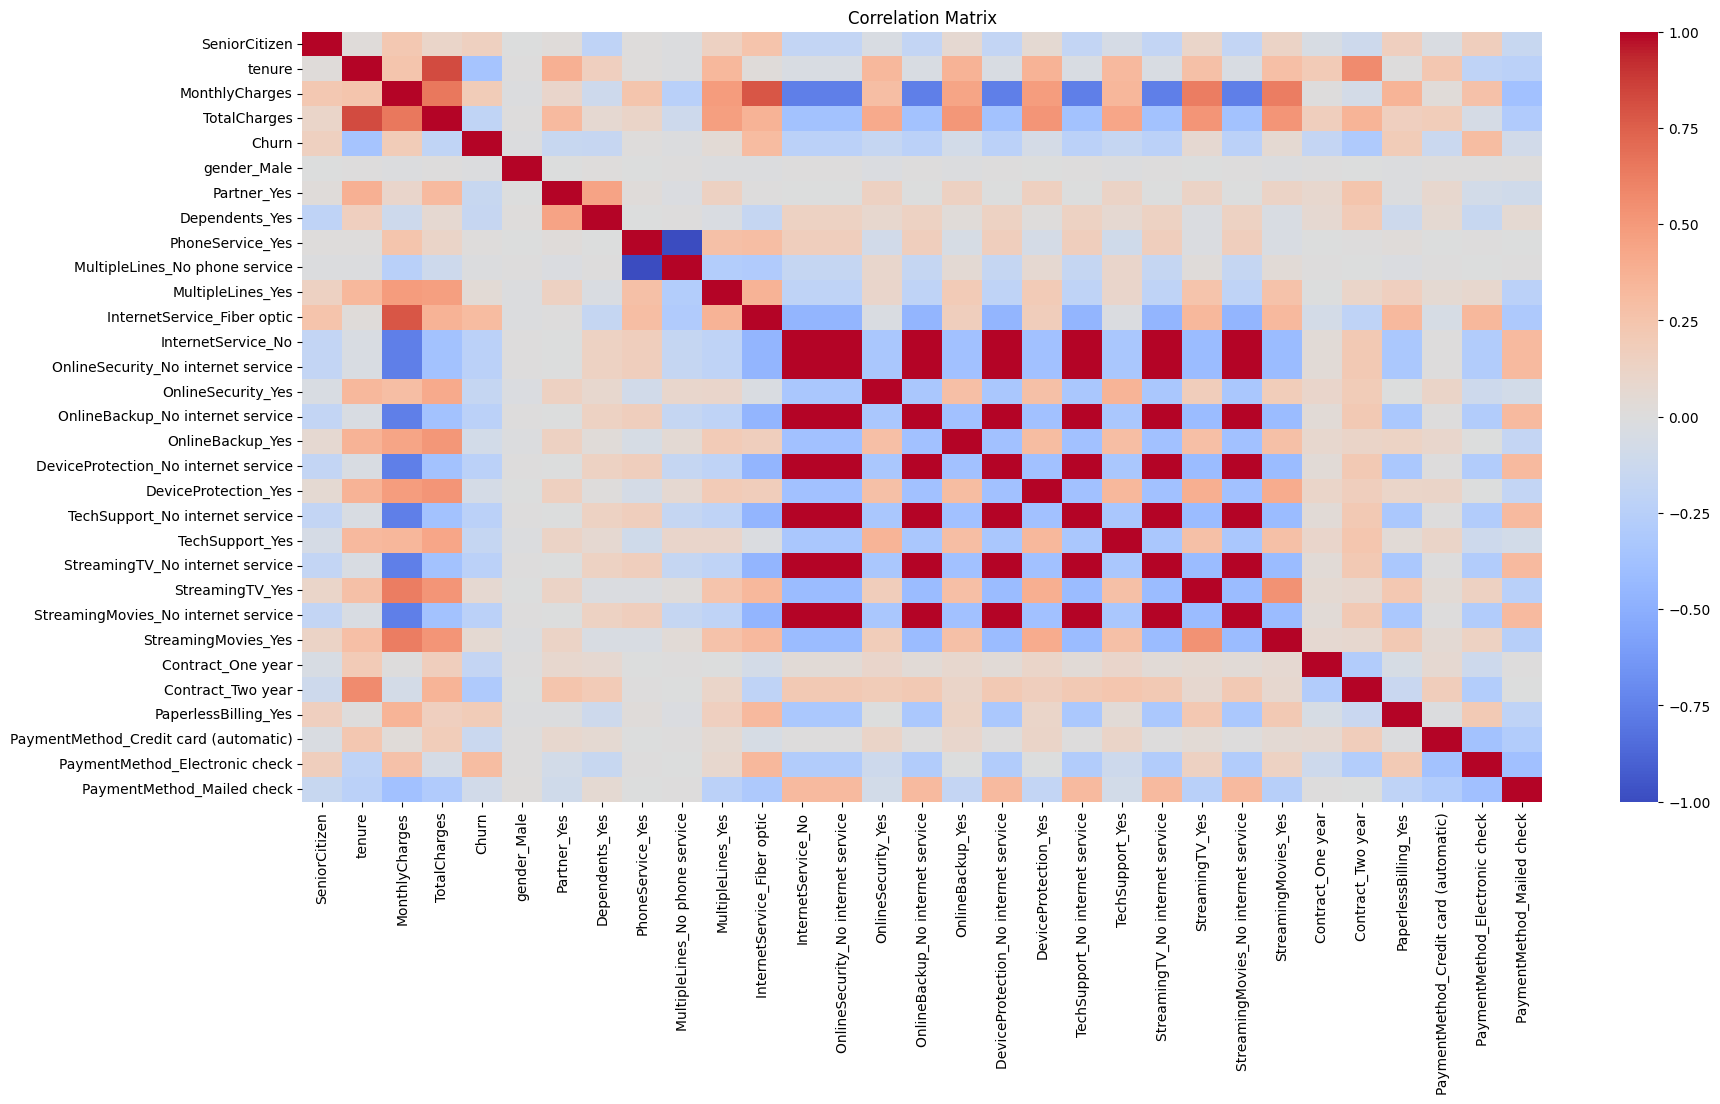

In [341]:
# 12. Create a correlation plot to visualise the correlation between features and the target variable “Churn”. 

# Set chart size
plt.figure(figsize=(20,10))

# Visualise feauture correlation using seaborn heatmap
sns.heatmap(telecom_cust_dummies.corr(), cmap='coolwarm')

# Add title
plt.title("Correlation Matrix")
plt.show()

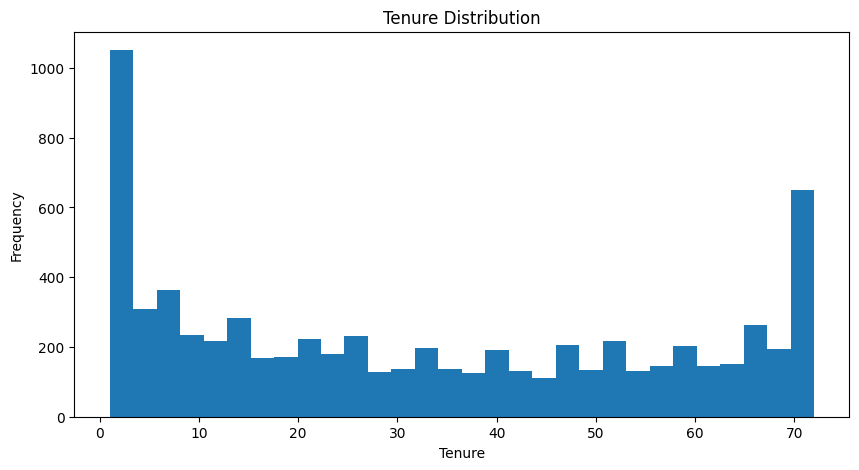

In [342]:
# 13. Create a histogram of the “tenure” column. 

# Set chart size
plt.figure(figsize=(10,5))

# Create histogram of tenure 
plt.hist(df['tenure'], bins=30)

# Add x,y labels and chart title
plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

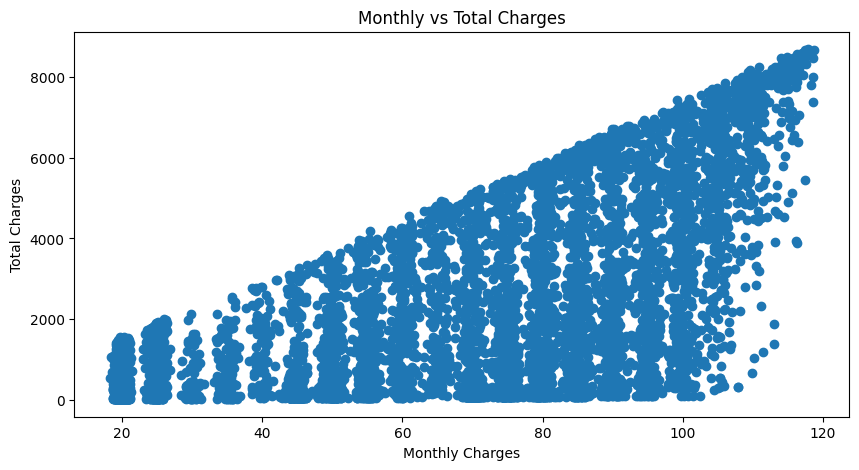

In [343]:
# 14. Create a scatter plot of “MonthlyCharges” vs. “TotalCharges”. 

# Set chart size
plt.figure(figsize=(10,5))

# Create scatterplot and enter parameters
plt.scatter(df['MonthlyCharges'], df['TotalCharges'])

# Add x,y labels and chart title
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.title("Monthly vs Total Charges")
plt.show()

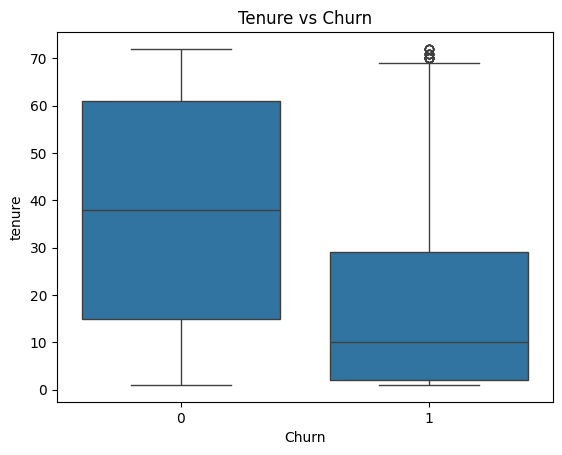

In [344]:
# 15. Create a box plot to compare “tenure” for churned and non-churned customers. 

# Create boxplot and enter parameters
sns.boxplot(x='Churn', y='tenure', data=df)

# Add chart title
plt.title("Tenure vs Churn")
plt.show()

### Preparations for ML Training

In [345]:
# 16. Scale all the variables to a range of 0 to 1 using min-max scaling. 

X = telecom_cust_dummies.drop('Churn', axis=1)
y = telecom_cust_dummies['Churn']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [346]:
# 17. Split the dataset into training and test sets (X_train; X_test; y_train; y_test) with a test size of 25%. 

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

## Modeling Strategy
We test multiple models to balance interpretability and performance.

Logistic Regression provides explainability, while tree-based models capture non-linear relationships.

### Logistic regression model 

In [347]:
# 18. Import and train a logistic regression model on the training data.

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [348]:
# 19. Make predictions on the test data. 

y_pred_log = log_model.predict(X_test)

In [349]:
# 20. Calculate and print the accuracy score of the logistic regression model.

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Accuracy: 0.7912400455062572


### Random forest model 

In [350]:
# 21. Create a random forest classifier and tune the following hyperparameters:

rf_model = RandomForestClassifier(
    n_estimators=2000,
    oob_score=True,
    max_features='sqrt',
    max_leaf_nodes=50,
    bootstrap=True,
    random_state=42
)

In [351]:
# 22. Fit the model. 

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",2000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",50
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [352]:
# 23. Make predictions on the new test data. 

y_pred_rf = rf_model.predict(X_test)

In [353]:
# 24. Calculate and print the accuracy score of the random forest classifier. 

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.7935153583617748


In [354]:
# 25. Calculate and print the OOB error estimation. Explain how well the model generalises to unseen data. 

oob_error = 1 - rf_model.oob_score_
print("OOB Error:", oob_error)

OOB Error: 0.192643155100493


In [355]:
# 26. Implement code to calculate the confusion matrix for both the logistic regression and random forest models.

print("Logistic Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print()
print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Logistic Confusion Matrix:
 [[1154  146]
 [ 221  237]]

RF Confusion Matrix:
 [[1187  113]
 [ 250  208]]


## Model Evaluation
We prioritise recall and F1-score to ensure high-risk customers are correctly identified.

In [356]:
# 27. Compute the precision and recall scores for each model. 

print("Logistic Precision:", precision_score(y_test, y_pred_log))
print("Logistic Recall:", recall_score(y_test, y_pred_log))
print()
print("RF Precision:", precision_score(y_test, y_pred_rf))
print("RF Recall:", recall_score(y_test, y_pred_rf))

Logistic Precision: 0.618798955613577
Logistic Recall: 0.517467248908297

RF Precision: 0.6479750778816199
RF Recall: 0.45414847161572053


In [357]:
# 28. Discuss what the confusion matrix reveals about the model's performance. 

**Logistic Regression**

TN (True Negatives) = 1154 = correctly predicted a customer will renew their subscription  

FP (False Positives) = 146 = incorrectly predicted a custoemr would end their subscription 

FN (False Negatives) = 221 = incorrectly predicted a customer would renew their subscription 

TP (True Positives) = 237 = correctly predicted a customer would end their subscription and they did



**Random Forest Model**

TN (True Negatives) = 1187 = correctly predicted a customer will renew their subscription 

FP (False Positives) = 113 = incorrectly predicted a custoemr would end their subscription 

FN (False Negatives) = 250 = incorrectly predicted a customer would renew their subscription 

TP (True Positives) = 208 = correctly predicted a customer would end their subscription and they did



In [358]:
# Analyse the precision and recall scores to understand the trade-off between correctly and incorrectly identifying churned customers. 

The logistic regression model achieves a precision of 0.619 and a recall of 0.517, while the random forest model achieves a higher precision of 0.648 but a lower recall of 0.454.

The logistic regression model demonstrates better recall, meaning it is more effective at identifying customers who are likely to churn, although it produces more false positives than the random forest model.

This indicates that the random forest model is more precise in predicting churn, predicting fewer false positives. However, it fails to correctly predict a larger proportion of actual churned customers.


In [359]:
# 29. Compare the logistic regression and random forest models based on these additional metrics. 
# Which model is more suitable for this specific task, and why? 

In the customer churn context, recall is more critical because failing to identify customer churn (false negatives) can lead to significant revenue loss. 

The logistic regression model is more suitable for this task, as it is better to have slightly more false positives but less false negatives (unanticipated loss of businesss).

## Key Findings

- Month-to-month contracts significantly increase churn risk
- Customers with higher charges are more likely to leave
- Longer tenure strongly reduces churn probability

## Business Impact

By identifying high-risk customers early, companies can:

- Reduce churn through targeted retention campaigns
- Improve customer lifetime value
- Increase profitability

This model can be integrated into CRM systems to flag at-risk customers in real time.